In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import time
from multiprocessing import Pool
from tqdm.auto import tqdm
import re

import numpy as np
from scipy import integrate
from matplotlib import pyplot as plt

import noctiluca as nl
import bayesmsd

/home/sgh/gitlibs/chromatin_dynamics/.venv_SD_py39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
import matplotlib as mpl
import matplotlib.colors as mplc

mpl.rcParams['figure.dpi'] = 600

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "DejaVu Sans"
mpl.rcParams['font.size'] = 6

mpl.rcParams['xtick.major.size'] = 2
mpl.rcParams['xtick.major.pad'] = 1
mpl.rcParams['ytick.major.size'] = 2
mpl.rcParams['ytick.major.pad'] = 1
mpl.rcParams['xtick.minor.size'] = 1
mpl.rcParams['xtick.minor.pad'] = 0.5
mpl.rcParams['ytick.minor.size'] = 1
mpl.rcParams['ytick.minor.pad'] = 0.5
mpl.rcParams['axes.labelpad'] = 1
mpl.rcParams['axes.titlepad'] = 3
mpl.rcParams['axes.titlelocation'] = 'left'
mpl.rcParams['legend.handletextpad'] = 0.4
mpl.rcParams['legend.columnspacing'] = 1.0
mpl.rcParams['legend.frameon'] = False

mpl.rcParams['figure.subplot.top'] = 0.75
mpl.rcParams['figure.subplot.bottom'] = 0.25
mpl.rcParams['figure.subplot.left'] = 0.25
mpl.rcParams['figure.subplot.right'] = 0.75

In [3]:
filename = '/data/sgh/science/2024_minflux/20260106_chromatin_dynamics_all_data.h5'
data = nl.io.load.hdf5(filename, '/data')

In [4]:
colors = {
    'blue'    : '#0077BB',
    'cyan'    : '#33BBEE',
    'teal'    : '#009988',
    'orange'  : '#EE7733',
    'red'     : '#CC3311',
    'magenta' : '#EE3377',
    'grey'    : '#BBBBBB',
}

In [35]:
conditions = [
    ['H2B', 'minflux', 'U2OS', 'ctrl'],
    ['H2B', 'minflux', 'U2OS', 'DRB'],
    ['H2B', 'minflux', 'U2OS', 'TSA'],
    ['H2B', 'minflux', 'U2OS', 'ICRF'],
    ['H2B', 'minflux', 'RPE', 'ctrl'],
    ['H2B', 'minflux', 'MEF', 'ctrl'],
    ['H2B', 'minflux', 'RH30', 'ctrl'],
    ['H2B', 'minflux', 'mESC', 'ctrl'],
    ['H2B', 'minflux', 'mESC', 'DRB'],
    ['H2B', 'minflux', 'mESC', 'TSA'],
    ['H2B', 'minflux', 'mESC', 'ICRF'],
    ['array', 'minflux', 'C36'],
    ['array', 'minflux', 'ΔRAD21 (inactive)'],
    ['array', 'minflux', 'ΔRAD21 (active)'],
    ['H2B', 'SPT-100ms', 'U2OS', 'ctrl'],
    ['H2B', 'SPT-100ms', 'U2OS', 'DRB'],
    ['H2B', 'SPT-100ms', 'U2OS', 'TSA'],
    ['H2B', 'SPT-100ms', 'U2OS', 'ICRF'],
    ['H2B', 'SPT-100ms', 'RPE', 'ctrl'],
    ['H2B', 'SPT-100ms', 'MEF', 'ctrl'],
    ['H2B', 'SPT-100ms', 'RH30', 'ctrl'],
    ['H2B', 'SPT-100ms', 'mESC', 'ctrl'],
    ['H2B', 'SPT-100ms', 'mESC', 'DRB'],
    ['H2B', 'SPT-100ms', 'mESC', 'TSA'],
    ['H2B', 'SPT-100ms', 'mESC', 'ICRF'],
    ['array', 'SPT-100ms', 'C36'],
    ['array', 'SPT-100ms', 'ΔRAD21 (inactive)'],
    ['array', 'SPT-100ms', 'ΔRAD21 (active)'],
    ['H2B', 'SPT-2s', 'U2OS', 'ctrl'],
    ['H2B', 'SPT-2s', 'U2OS', 'DRB'],
    ['H2B', 'SPT-2s', 'U2OS', 'TSA'],
    ['H2B', 'SPT-2s', 'U2OS', 'ICRF'],
    ['H2B', 'SPT-2s', 'RPE', 'ctrl'],
    ['H2B', 'SPT-2s', 'MEF', 'ctrl'],
    ['H2B', 'SPT-2s', 'RH30', 'ctrl'],
    ['H2B', 'SPT-2s', 'mESC', 'ctrl'],
    ['H2B', 'SPT-2s', 'mESC', 'DRB'],
    ['H2B', 'SPT-2s', 'mESC', 'TSA'],
    ['H2B', 'SPT-2s', 'mESC', 'ICRF'],
    ['array', 'SPT-2s', 'C36'],
    ['array', 'SPT-2s', 'ΔRAD21 (inactive)'],
    ['array', 'SPT-2s', 'ΔRAD21 (active)'],
    ['array', 'SRLCI', 'C36'],
    ['array', 'SRLCI', 'ΔRAD21 (inactive)'],
    ['array', 'SRLCI', 'ΔRAD21 (active)'],
]

In [6]:
def lens_for_condition(tags):
    data.makeSelection(tags, logic=all)
    return np.array([traj.F for traj in data])

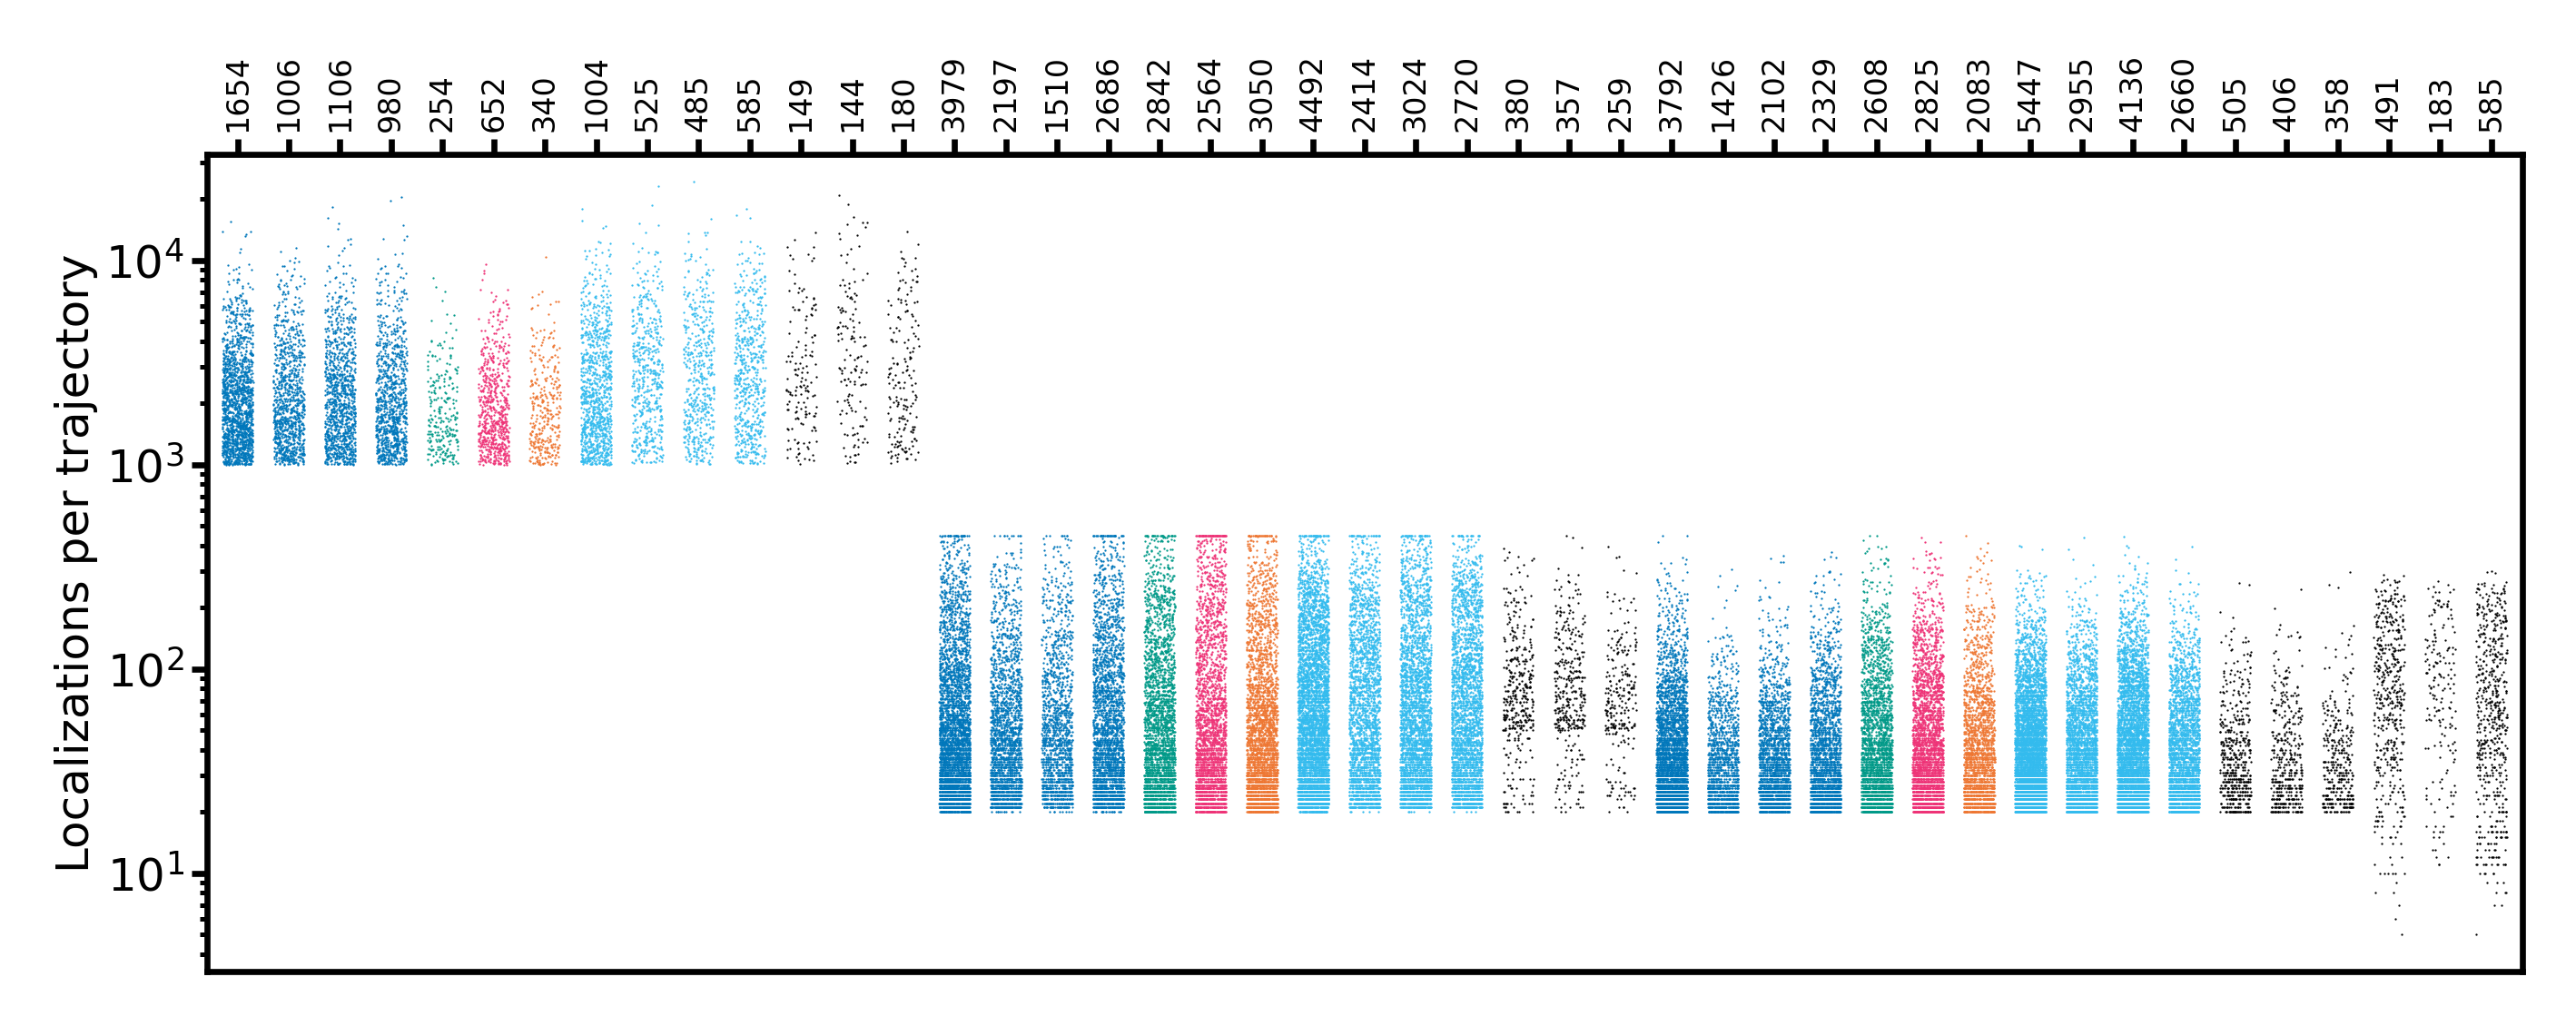

In [71]:
lens = list(map(lens_for_condition, conditions))

ct_colors = {
    'U2OS' : colors['blue'],
    'RPE' : colors['teal'],
    'MEF' : colors['magenta'],
    'RH30' : colors['orange'],
    'mESC' : colors['cyan'],
    'array' : 'k',#colors['cyan'],
}

fig = plt.figure(figsize=[8.5, 3])
ax = fig.gca()

# boxlinestyle=dict(color=colors['grey'], linewidth=0.5)
# ax.boxplot(
#     lens,
#     widths=0.8,
#     showfliers=False,
#     boxprops=boxlinestyle,
#     whiskerprops=boxlinestyle,
#     capprops=boxlinestyle,
#     medianprops=boxlinestyle,
# )

for (i, L), cond in zip(enumerate(lens, start=1), conditions):
    color=colors['grey']
    for key, col in ct_colors.items():
        if key in cond:
            color = col
    
    x = i + 0.6*(np.random.rand(len(L))-0.5)
    ax.scatter(
        x, L,
        marker='.',
        s=0.3,
        linewidth=0,
        color=color,
    )

ax.set_yscale('log')
ax.xaxis.set_ticks_position('top')
ax.set_xticks([i+1 for i in range(len(lens))])
ax.set_xticklabels([str(len(L)) for L in lens], rotation=90, fontsize=4)
ax.set_ylabel('Localizations per trajectory')
ax.set_xlim([0.4, 45.6])
ax.set_ylim([3.3, 3.3e4])

# plt.savefig('/data/sgh/science/2024_minflux/plots/fig1/trajectory_lengths.pdf')
plt.savefig('/data/sgh/science/2024_minflux/plots/fig1/trajectory_lengths.png', dpi=600)
plt.show()